# GEE SegFormer Training — Florida Mangrove Segmentation

End-to-end pipeline for training SegFormer on GEE Sentinel-2 + Embedding tiles using the **full 11-class ESA WorldCover taxonomy** — no classes are merged or collapsed.

| Idx | ESA Value | Class Name |
|-----|-----------|------------|
| 0 | 10 | Tree Cover |
| 1 | 20 | Shrubland |
| 2 | 30 | Grassland |
| 3 | 40 | Cropland |
| 4 | 50 | Built-up (human infrastructure) |
| 5 | 60 | Bare / Sparse Vegetation |
| 6 | 70 | Snow and Ice |
| 7 | 80 | Water |
| 8 | 90 | Wetland |
| 9 | 95 | Mangrove |
| 10 | 100 | Moss / Lichen |

**Data** — `Florida_Training_Dataset/` (~100 tiles, 2048×2048, 69 bands each)
- Bands 1–4: Sentinel-2 optical RGBN (raw reflectance ×10 000)
- Bands 5–68: Google Satellite Embeddings (64-d float32)
- Band 69: ESA WorldCover multi-class label

**Reused from `DroneClassification/`**: `SegFormer`, `JaccardLoss`, `TrainingSession`

## Section 0 — Imports & Configuration

In [1]:
import sys
import os
import json
import random
import warnings
import numpy as np
import torch
import torch.nn as nn
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

warnings.filterwarnings('ignore')

# ── Add DroneClassification modules to sys.path ──────────────────────────────
_DC_ROOT = Path('../../DroneClassification').resolve()
sys.path.insert(0, str(_DC_ROOT))

from models import SegFormer
from models.loss import JaccardLoss
from training_utils import TrainingSession

print('DroneClassification modules loaded from:', _DC_ROOT)

DroneClassification modules loaded from: C:\vscode workspace\ml-mangrove\DroneClassification


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
#  CONFIGURATION  — edit these to match your setup
# ══════════════════════════════════════════════════════════════════════════════

DATA_ROOT       = Path('./Florida_Training_Dataset')
STATS_FILE      = Path('./gee_norm_stats.json')       # cached per-channel stats
CACHE_DIR       = Path('./chip_cache')                 # pre-extracted .npz chips
EXPERIMENT_NAME = 'gee_segformer_florida_v4'

# ── Patch & input ─────────────────────────────────────────────────────────────
PATCH_SIZE  = 512    # sub-tile size fed to the model (must divide 2048 evenly)
TILE_STRIDE = 256    # sliding-window stride; < PATCH_SIZE → overlapping chips
                     # 256 with 512 patch = 50% overlap → ~4× more chips per tile

# Feature channels to use:
#   'rgb'        → bands 0-2  (Red, Green, Blue)              [3 ch]
#   'rgbn'       → bands 0-3  (Red, Green, Blue, NIR)         [4 ch]
#   'embeddings' → bands 4-67 (Google Satellite Embeddings)   [64 ch]
#   'full'       → bands 0-67 (RGBN + Embeddings)             [68 ch]  ← recommended
INPUT_MODE  = 'full'
_INPUT_MODE_CHANNELS = {'rgb': 3, 'rgbn': 4, 'embeddings': 64, 'full': 68}

# ── Label mapping ─────────────────────────────────────────────────────────────
# 6-class taxonomy. Cropland (40) and Bare/Sparse (60) are excluded due to
# insufficient data in Florida — their pixels become IGNORE_INDEX.
# Shrubland (20), Snow/Ice (70), Moss/Lichen (100) also excluded (absent).
ESA_TO_CLASS = {
    10:  0,   # Tree cover
    30:  1,   # Grassland
    50:  2,   # Built-up (human infrastructure: buildings, roads)
    80:  3,   # Permanent water bodies
    90:  4,   # Herbaceous wetland
    95:  5,   # Mangroves
}
CLASS_NAMES = [
    'Tree Cover',    #  0  (ESA 10)
    'Grassland',     #  1  (ESA 30)
    'Built-up',      #  2  (ESA 50)
    'Water',         #  3  (ESA 80)
    'Wetland',       #  4  (ESA 90)
    'Mangrove',      #  5  (ESA 95)
]
CLASS_COLORS = np.array([
    [0.05, 0.40, 0.05],   #  0 Tree Cover  — dark green
    [0.70, 0.80, 0.20],   #  1 Grassland   — yellow-green
    [0.90, 0.20, 0.20],   #  2 Built-up    — red
    [0.10, 0.40, 0.95],   #  3 Water       — blue
    [0.50, 0.80, 0.40],   #  4 Wetland     — light green
    [0.05, 0.75, 0.45],   #  5 Mangrove    — teal
])
NUM_CLASSES  = len(CLASS_NAMES)   # 6
IGNORE_INDEX = 255

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE   = 2
NUM_EPOCHS   = 100
INIT_LR      = 5e-5
WEIGHT_DECAY = 0.01
NUM_WORKERS  = 0        # safe with CachedChipDataset (pure numpy loads, no rasterio)
VAL_SPLIT    = 0.2      # fraction of tiles held out for validation
RANDOM_SEED  = 42

# ── SegFormer checkpoint ──────────────────────────────────────────────────────
SEGFORMER_WEIGHTS = 'nvidia/segformer-b4-finetuned-ade-512-512'

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# ── Summary ───────────────────────────────────────────────────────────────────
all_tiles = sorted(DATA_ROOT.glob('*.tif'))
print(f'Device    : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU       : {torch.cuda.get_device_name(0)}')
    print(f'VRAM      : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')
print(f'Tiles dir : {DATA_ROOT.resolve()}')
print(f'Num tiles : {len(all_tiles)}')
print(f'Input mode: {INPUT_MODE}  ({_INPUT_MODE_CHANNELS[INPUT_MODE]} channels)')
print(f'Num classes: {NUM_CLASSES}  — {CLASS_NAMES}')
print(f'Excluded  : Cropland, Bare/Sparse (data-limited), Shrubland/Snow/Moss (absent)')

Device    : cuda
GPU       : NVIDIA GeForce RTX 4060
VRAM      : 8.0 GB
Tiles dir : C:\vscode workspace\ml-mangrove\Scale Adaption\GEE\Florida_Training_Dataset
Num tiles : 102
Input mode: full  (68 channels)
Num classes: 6  — ['Tree Cover', 'Grassland', 'Built-up', 'Water', 'Wetland', 'Mangrove']
Excluded  : Cropland, Bare/Sparse (data-limited), Shrubland/Snow/Moss (absent)


## Section 1 — Data Exploration

Inspect a sample tile to understand band layout, value ranges, and label distribution.

In [3]:
sample_path = all_tiles[0]
print(f'Tile: {sample_path.name}')

with rasterio.open(sample_path) as src:
    print(f'\nRasterio metadata')
    print(f'  Shape  : {src.height} x {src.width}')
    print(f'  Bands  : {src.count}')
    print(f'  CRS    : {src.crs}')
    print(f'  Nodata : {src.nodata}')
    print(f'  Dtype  : {src.dtypes[0]}')
    print()

    # Read all bands for inspection
    data = src.read()   # (69, H, W)

print('Band stats (min / mean / max):')
labels_to_check = {
    'Red   (B0)': 0,
    'Green (B1)': 1,
    'Blue  (B2)': 2,
    'NIR   (B3)': 3,
    'Embed0(B4)': 4,
    'Embed1(B5)': 5,
    'Label (B68)': 68,
}
for name, idx in labels_to_check.items():
    b = data[idx]
    print(f'  {name}: {b.min():.3f} / {b.mean():.3f} / {b.max():.3f}')

print()
unique_labels, counts = np.unique(data[68], return_counts=True)
print('ESA label distribution in this tile:')
esa_names = {10:'Tree Cover', 20:'Shrubland', 30:'Grassland', 40:'Cropland',
             50:'Built-up', 60:'Bare', 80:'Water', 90:'Wetland', 95:'Mangrove', 100:'Moss'}
total_px = data[68].size
for val, cnt in zip(unique_labels, counts):
    ival = int(val)
    name = esa_names.get(ival, f'Unknown({ival})')
    print(f'  ESA {ival:3d}  {name:12s}: {cnt:8,} px  ({100*cnt/total_px:.1f}%)')

Tile: FL_Training_Tile_001.tif

Rasterio metadata
  Shape  : 2049 x 2048
  Bands  : 69
  CRS    : EPSG:3857
  Nodata : -inf
  Dtype  : float64

Band stats (min / mean / max):
  Red   (B0): 38.000 / 444.587 / 4082.000
  Green (B1): 73.000 / 962.336 / 4172.000
  Blue  (B2): 0.000 / 1021.705 / 4036.000
  NIR   (B3): 0.000 / 235.813 / 5180.000
  Embed0(B4): -0.080 / 0.058 / 0.160
  Embed1(B5): -0.355 / -0.081 / 0.045
  Label (B68): 10.000 / 80.061 / 95.000

ESA label distribution in this tile:
  ESA  10  Tree Cover  :      126 px  (0.0%)
  ESA  20  Shrubland   :        3 px  (0.0%)
  ESA  30  Grassland   :    1,876 px  (0.0%)
  ESA  50  Built-up    :       23 px  (0.0%)
  ESA  60  Bare        :      651 px  (0.0%)
  ESA  80  Water       : 4,167,794 px  (99.3%)
  ESA  90  Wetland     :    3,061 px  (0.1%)
  ESA  95  Mangrove    :   22,818 px  (0.5%)


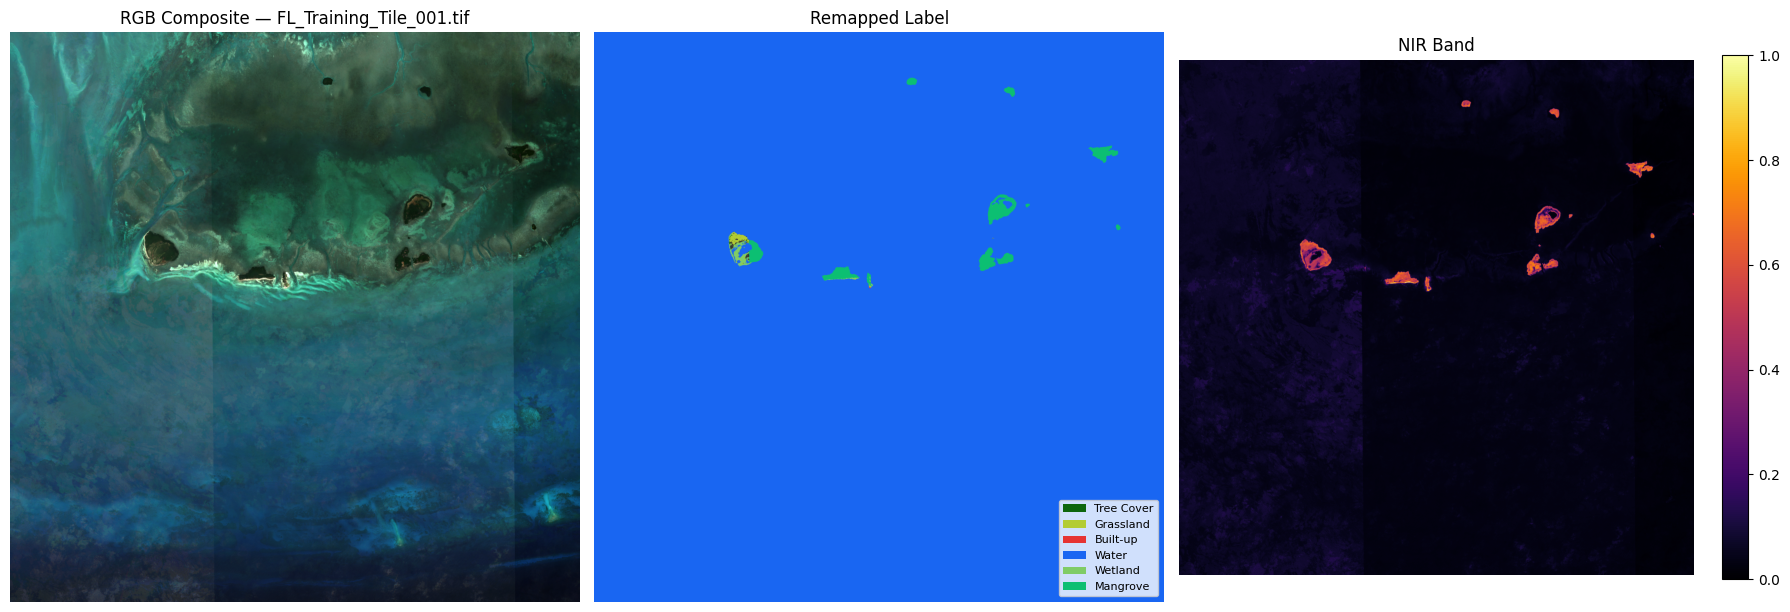

In [4]:
# Visualize RGB composite and label map for the sample tile
def make_label_rgb(label_2d, class_colors, ignore_index=255):
    """Convert integer label map to RGB for display."""
    rgb = np.zeros((*label_2d.shape, 3), dtype=np.float32)
    for i, color in enumerate(class_colors):
        rgb[label_2d == i] = color
    rgb[label_2d == ignore_index] = [0.2, 0.2, 0.2]
    return rgb

# Scale S2 optical to 0-1 (raw values are reflectance × 10000)
rgb = np.stack([
    np.clip(data[0] / 3000.0, 0, 1),   # Red
    np.clip(data[1] / 3000.0, 0, 1),   # Green
    np.clip(data[2] / 3000.0, 0, 1),   # Blue
], axis=-1)

# Remap ESA label to class indices
raw_label = data[68]
remapped  = np.full_like(raw_label, fill_value=IGNORE_INDEX)
for esa_val, cls_idx in ESA_TO_CLASS.items():
    remapped[raw_label == esa_val] = cls_idx

label_rgb = make_label_rgb(remapped, CLASS_COLORS, IGNORE_INDEX)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(rgb)
axes[0].set_title(f'RGB Composite — {sample_path.name}', fontsize=12)
axes[0].axis('off')

axes[1].imshow(label_rgb)
axes[1].set_title('Remapped Label', fontsize=12)
axes[1].axis('off')

# Legend
patches = [mpatches.Patch(facecolor=CLASS_COLORS[i], label=CLASS_NAMES[i])
           for i in range(NUM_CLASSES)]
axes[1].legend(handles=patches, loc='lower right', fontsize=8, framealpha=0.8)

# NIR band
nir_display = np.clip(data[3] / 5000.0, 0, 1)
im = axes[2].imshow(nir_display, cmap='inferno')
axes[2].set_title('NIR Band', fontsize=12)
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

del data  # free memory

## Section 2 — Dataset

`GEETileDataset` lazily reads 512×512 chips from 2048×2048 GeoTIFFs using rasterio windowed reads.

Band layout (0-indexed):
- `0–3`   : RGBN optical
- `4–67`  : Google Satellite Embeddings (64-d)
- `68`    : ESA WorldCover label (raw values, remapped at `__getitem__` time)

In [5]:
# Band index groups (0-based; rasterio reads with +1)
_BAND_GROUPS = {
    'rgb'       : list(range(0, 3)),
    'rgbn'      : list(range(0, 4)),
    'embeddings': list(range(4, 68)),
    'full'      : list(range(0, 68)),
}
_LABEL_BAND = 68   # 0-based


class GEETileDataset(Dataset):
    """
    Lazy-loading dataset for GEE 69-band Sentinel-2 GeoTIFFs.

    Each 2048×2048 tile is sampled with a sliding window of size PATCH_SIZE
    and step TILE_STRIDE.  TILE_STRIDE < PATCH_SIZE gives overlapping chips,
    which increases the effective dataset size without collecting new data.

    Chips where the valid label coverage falls below `min_valid_ratio`
    (e.g. tile edges with nodata) are skipped.

    Returns: (features [C, H, W] float32, label [H, W] int64)
      - feature values are z-score normalised per channel when norm_stats given
      - label values are remapped via label_map; unknown pixels → ignore_index
    """

    def __init__(
        self,
        tile_paths,
        mode='full',
        patch_size=512,
        tile_stride=None,       # None → non-overlapping (= patch_size)
        label_map=None,
        norm_stats=None,
        augment=False,
        min_valid_ratio=0.3,
        ignore_index=255,
    ):
        self.tile_paths    = [str(p) for p in tile_paths]
        self.patch_size    = patch_size
        self.tile_stride   = tile_stride if tile_stride is not None else patch_size
        self.feature_bands = _BAND_GROUPS[mode]
        self.label_map     = label_map or {}
        self.augment       = augment
        self.ignore_index  = ignore_index

        if norm_stats is not None:
            all_mean = np.array(norm_stats['mean'], dtype=np.float32)
            all_std  = np.array(norm_stats['std'],  dtype=np.float32)
            self.mean = all_mean[self.feature_bands]
            self.std  = all_std[self.feature_bands]
        else:
            self.mean = None
            self.std  = None

        self.catalog = self._build_catalog(min_valid_ratio)
        print(f'  {len(self.catalog):,} chips ({patch_size}×{patch_size}, stride={self.tile_stride}) '
              f'from {len(tile_paths)} tiles (min_valid={min_valid_ratio})')

    # ------------------------------------------------------------------
    def _build_catalog(self, min_valid_ratio):
        known_esa = set(self.label_map.keys())
        catalog = []
        for path in tqdm(self.tile_paths, desc='Cataloguing tiles', leave=False):
            with rasterio.open(path) as src:
                H, W   = src.height, src.width
                nodata = src.nodata        # e.g. -inf
                # Sliding window over the tile
                for row_off in range(0, H - self.patch_size + 1, self.tile_stride):
                    for col_off in range(0, W - self.patch_size + 1, self.tile_stride):
                        win = rasterio.windows.Window(
                            col_off, row_off, self.patch_size, self.patch_size
                        )
                        label = src.read(_LABEL_BAND + 1, window=win)  # float64
                        # Valid = finite pixels that belong to a known ESA class
                        finite = np.isfinite(label)
                        if nodata is not None and np.isfinite(nodata):
                            finite &= (label != nodata)
                        valid = np.isin(label[finite].astype(np.int32), list(known_esa))
                        valid_ratio = valid.sum() / label.size if label.size > 0 else 0.0
                        if valid_ratio >= min_valid_ratio:
                            catalog.append((path, row_off, col_off))
        return catalog

    # ------------------------------------------------------------------
    def __len__(self):
        return len(self.catalog)

    # ------------------------------------------------------------------
    def __getitem__(self, idx):
        path, row_off, col_off = self.catalog[idx]
        win = rasterio.windows.Window(
            col_off, row_off, self.patch_size, self.patch_size
        )
        with rasterio.open(path) as src:
            feat_idx_1 = [b + 1 for b in self.feature_bands]  # rasterio 1-indexed
            features   = src.read(feat_idx_1, window=win).astype(np.float32)  # (C,H,W)
            label_f    = src.read(_LABEL_BAND + 1, window=win)                # float64

        # Replace non-finite feature pixels (nodata=-inf) with 0 so they
        # are neutral after z-score normalization (mean subtraction → 0).
        features = np.where(np.isfinite(features), features, 0.0)

        # Replace non-finite label pixels with sentinel before int cast
        label_f = np.where(np.isfinite(label_f), label_f, -1.0)
        label   = label_f.astype(np.int64)   # -1 for nodata pixels

        # Normalise features
        if self.mean is not None:
            features = (features - self.mean[:, None, None]) / (self.std[:, None, None] + 1e-8)

        # Remap ESA labels → class indices; everything else → ignore_index
        remapped = np.full_like(label, fill_value=self.ignore_index)
        for esa_val, class_idx in self.label_map.items():
            remapped[label == esa_val] = class_idx
        label = remapped

        # Augmentation (flip + 90° rotation)
        if self.augment:
            if random.random() > 0.5:
                features = np.flip(features, axis=2).copy()
                label    = np.flip(label,    axis=1).copy()
            if random.random() > 0.5:
                features = np.flip(features, axis=1).copy()
                label    = np.flip(label,    axis=0).copy()
            k = random.randint(0, 3)
            if k:
                features = np.rot90(features, k=k, axes=(1, 2)).copy()
                label    = np.rot90(label,    k=k, axes=(0, 1)).copy()

        return torch.from_numpy(features), torch.from_numpy(label).long()


print('GEETileDataset defined.')

GEETileDataset defined.


## Section 3 — Normalization Statistics

Compute per-channel mean and std by sub-sampling pixels from all tiles.
Results are cached to `gee_norm_stats.json` so this only runs once.

In [6]:
def compute_norm_stats(tile_paths, feature_bands, sample_stride=16):
    """
    Streaming mean/std estimation via sub-sampling every `sample_stride`-th pixel.
    Only reads feature bands (not the label band).

    Non-finite values (nodata=-inf from GEE tiles) are excluded per band so
    that pixels at tile edges or masked regions don't corrupt the statistics.

    Returns (mean, std) as float32 arrays of shape (len(feature_bands),).
    """
    n = len(feature_bands)
    sums    = np.zeros(n, dtype=np.float64)
    sq_sums = np.zeros(n, dtype=np.float64)
    counts  = np.zeros(n, dtype=np.int64)   # per-band finite pixel count

    feat_1idx = [b + 1 for b in feature_bands]   # rasterio 1-indexed
    for path in tqdm(tile_paths, desc='Computing norm stats'):
        with rasterio.open(path) as src:
            data = src.read(feat_1idx).astype(np.float64)   # (C, H, W)
        data = data[:, ::sample_stride, ::sample_stride]    # subsample
        data = data.reshape(n, -1)                          # (C, N)
        for c in range(n):
            valid = data[c][np.isfinite(data[c])]           # exclude -inf / nan
            sums[c]    += valid.sum()
            sq_sums[c] += (valid ** 2).sum()
            counts[c]  += valid.size

    mean = (sums / counts).astype(np.float32)
    var  = (sq_sums / counts - (sums / counts) ** 2).clip(0)
    std  = np.sqrt(var).astype(np.float32)
    return mean, std


# All 68 feature bands (stats stored for all; dataset selects subset by mode)
ALL_FEATURE_BANDS = list(range(68))

if STATS_FILE.exists():
    with open(STATS_FILE) as f:
        norm_stats = json.load(f)
    print(f'Loaded cached stats from {STATS_FILE}')
else:
    print('Computing normalization statistics (runs once, then cached)...')
    mean, std = compute_norm_stats(all_tiles, ALL_FEATURE_BANDS, sample_stride=16)
    norm_stats = {'mean': mean.tolist(), 'std': std.tolist()}
    with open(STATS_FILE, 'w') as f:
        json.dump(norm_stats, f)
    print(f'Saved to {STATS_FILE}')

# Sanity check: print stats for RGBN bands
mean_arr = np.array(norm_stats['mean'])
std_arr  = np.array(norm_stats['std'])
print('\nNorm stats for RGBN bands (raw S2 reflectance units):')
for i, name in enumerate(['Red', 'Green', 'Blue', 'NIR']):
    print(f'  {name:5}: mean={mean_arr[i]:8.1f}, std={std_arr[i]:8.1f}')
print('\nNorm stats for first 4 embedding dims (B4–B7):')
for i in range(4, 8):
    print(f'  Embed {i-4}: mean={mean_arr[i]:8.4f}, std={std_arr[i]:8.4f}')
print('\nStats check (any NaN or Inf?):')
print(f'  mean: nan={np.isnan(mean_arr).any()}, inf={np.isinf(mean_arr).any()}')
print(f'  std : nan={np.isnan(std_arr).any()},  inf={np.isinf(std_arr).any()}')

Loaded cached stats from gee_norm_stats.json

Norm stats for RGBN bands (raw S2 reflectance units):
  Red  : mean=   436.1, std=   519.8
  Green: mean=   648.0, std=   472.1
  Blue : mean=   514.1, std=   436.0
  NIR  : mean=  1044.8, std=  1276.6

Norm stats for first 4 embedding dims (B4–B7):
  Embed 0: mean=  0.0576, std=  0.0428
  Embed 1: mean= -0.1218, std=  0.0926
  Embed 2: mean= -0.0983, std=  0.0935
  Embed 3: mean= -0.0274, std=  0.1010

Stats check (any NaN or Inf?):
  mean: nan=False, inf=False
  std : nan=False,  inf=False


## Section 4 — Train / Val Split & DataLoaders

Split is done **at the tile level** to prevent data leakage (chips from the same tile never appear in both train and val).

In [7]:
# Tile-level split
tile_list = list(all_tiles)
random.shuffle(tile_list)
n_val   = max(1, int(len(tile_list) * VAL_SPLIT))
val_tiles   = tile_list[:n_val]
train_tiles = tile_list[n_val:]

print(f'Tiles — train: {len(train_tiles)}, val: {len(val_tiles)}')
print()

print('Building training dataset...')
train_dataset = GEETileDataset(
    tile_paths      = train_tiles,
    mode            = INPUT_MODE,
    patch_size      = PATCH_SIZE,
    tile_stride     = TILE_STRIDE,
    label_map       = ESA_TO_CLASS,
    norm_stats      = norm_stats,
    augment         = True,
    min_valid_ratio = 0.3,
    ignore_index    = IGNORE_INDEX,
)

print('Building validation dataset...')
val_dataset = GEETileDataset(
    tile_paths      = val_tiles,
    mode            = INPUT_MODE,
    patch_size      = PATCH_SIZE,
    tile_stride     = PATCH_SIZE,   # no overlap in val — each pixel counted once
    label_map       = ESA_TO_CLASS,
    norm_stats      = norm_stats,
    augment         = False,
    min_valid_ratio = 0.3,
    ignore_index    = IGNORE_INDEX,
)

IN_CHANNELS = len(_BAND_GROUPS[INPUT_MODE])
print(f'\nInput channels : {IN_CHANNELS}  (mode={INPUT_MODE})')
print(f'Train chips    : {len(train_dataset):,}')
print(f'Val chips      : {len(val_dataset):,}')

Tiles — train: 82, val: 20

Building training dataset...


  4,018 chips (512×512, stride=256) from 82 tiles (min_valid=0.3)
Building validation dataset...


  320 chips (512×512, stride=512) from 20 tiles (min_valid=0.3)

Input channels : 68  (mode=full)
Train chips    : 4,018
Val chips      : 320


In [8]:
# ── Pre-extract chips to .npz for fast data loading ───────────────────────────
# Each __getitem__ currently opens a 69-band GeoTIFF and reads a 512×512 window
# (~67 MB) via rasterio. With NUM_WORKERS=0 this blocks the GPU between every
# batch.  Caching bakes in normalisation once and replaces rasterio reads with
# fast numpy loads, allowing num_workers > 0 without multiprocessing issues.
#
# Disk usage: float16 features (33.6 MB) + uint8 label (0.25 MB) per chip
# CACHE_DIR is configured in code-config
# ─────────────────────────────────────────────────────────────────────────────

n_chips    = len(train_dataset) + len(val_dataset)
bytes_chip = 68 * PATCH_SIZE * PATCH_SIZE * 2 + PATCH_SIZE * PATCH_SIZE  # fp16 + u8
print(f'Chips to cache : {n_chips:,}  (train={len(train_dataset):,}, val={len(val_dataset):,})')
print(f'Est. disk usage: {n_chips * bytes_chip / 1e9:.1f} GB  (float16 features + uint8 labels)')
print(f'Cache dir      : {CACHE_DIR.resolve()}')
print()


class CachedChipDataset(Dataset):
    """Loads pre-extracted chips from .npz files — no rasterio at train time."""

    def __init__(self, cache_dir, augment=False):
        self.files   = sorted(Path(cache_dir).glob('chip_*.npz'))
        self.augment = augment

        cat_path = Path(cache_dir) / 'catalog.json'
        if cat_path.exists():
            with open(cat_path) as f:
                raw = json.load(f)
            self.catalog = [(d['path'], d['row_off'], d['col_off']) for d in raw]
        else:
            self.catalog = None   # visualisation unavailable without catalog

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        d        = np.load(self.files[idx])
        features = d['features'].astype(np.float32)  # float16 → float32
        label    = d['label'].astype(np.int64)        # uint8   → int64

        if self.augment:
            if random.random() > 0.5:
                features = np.flip(features, axis=2).copy()
                label    = np.flip(label,    axis=1).copy()
            if random.random() > 0.5:
                features = np.flip(features, axis=1).copy()
                label    = np.flip(label,    axis=0).copy()
            k = random.randint(0, 3)
            if k:
                features = np.rot90(features, k=k, axes=(1, 2)).copy()
                label    = np.rot90(label,    k=k, axes=(0, 1)).copy()

        return torch.from_numpy(features), torch.from_numpy(label).long()


def _cache_split(dataset, cache_dir, split_name):
    split_dir = Path(cache_dir) / split_name
    split_dir.mkdir(parents=True, exist_ok=True)

    existing = {f.stem for f in split_dir.glob('chip_*.npz')}
    to_do    = [i for i in range(len(dataset)) if f'chip_{i:05d}' not in existing]

    if not to_do:
        print(f'{split_name}: all {len(dataset):,} chips already cached → {split_dir}')
    else:
        print(f'{split_name}: writing {len(to_do):,} chips → {split_dir}')
        for idx in tqdm(to_do, desc=f'Caching {split_name}'):
            features, label = dataset[idx]
            np.savez(
                split_dir / f'chip_{idx:05d}',
                features = features.numpy().astype(np.float16),
                label    = label.numpy().astype(np.uint8),
            )

    # Save catalog so visualisation cells can look up the source tile path
    cat_path = split_dir / 'catalog.json'
    if not cat_path.exists() and hasattr(dataset, 'catalog'):
        with open(cat_path, 'w') as f:
            json.dump([{'path': str(p), 'row_off': int(r), 'col_off': int(c)}
                       for p, r, c in dataset.catalog], f)

    return CachedChipDataset(split_dir, augment=(split_name == 'train'))


print('Caching train chips (runs once, skips existing) ...')
train_dataset = _cache_split(train_dataset, CACHE_DIR, 'train')
print(f'  → {len(train_dataset):,} chips\n')

print('Caching val chips ...')
val_dataset = _cache_split(val_dataset, CACHE_DIR, 'val')
print(f'  → {len(val_dataset):,} chips')

# train_dataset / val_dataset now point to CachedChipDataset —
# all downstream cells (loaders, class weights, visualisation) use them transparently.


Chips to cache : 4,338  (train=4,018, val=320)
Est. disk usage: 155.8 GB  (float16 features + uint8 labels)
Cache dir      : C:\vscode workspace\ml-mangrove\Scale Adaption\GEE\chip_cache

Caching train chips (runs once, skips existing) ...
train: all 4,018 chips already cached → chip_cache\train
  → 4,018 chips

Caching val chips ...
val: all 320 chips already cached → chip_cache\val
  → 320 chips


In [9]:
train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = NUM_WORKERS,
    pin_memory  = (DEVICE.type == 'cuda'),
    drop_last   = True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = (DEVICE.type == 'cuda'),
)

# Verify a batch
x_batch, y_batch = next(iter(train_loader))
print(f'Feature batch : {tuple(x_batch.shape)}  dtype={x_batch.dtype}')
print(f'Label batch   : {tuple(y_batch.shape)}   dtype={y_batch.dtype}')
print(f'Feature range : [{x_batch.min():.3f}, {x_batch.max():.3f}]')
unique_in_batch = torch.unique(y_batch).tolist()
readable = [CLASS_NAMES[v] if v < NUM_CLASSES else f'ignore({v})' for v in unique_in_batch]
print(f'Labels in batch: {readable}')
print(f'NaN/Inf check  : nan={torch.isnan(x_batch).any()}, inf={torch.isinf(x_batch).any()}')


Feature batch : (2, 68, 512, 512)  dtype=torch.float32
Label batch   : (2, 512, 512)   dtype=torch.int64
Feature range : [-4.895, 6.793]
Labels in batch: ['Tree Cover', 'Grassland', 'Built-up', 'Water', 'Wetland', 'ignore(255)']
NaN/Inf check  : nan=False, inf=False


## Section 5 — Model: GEESegFormer

Wraps the existing `SegFormer` from `DroneClassification/models/models.py` with a lightweight
**input projection** that maps the N satellite bands → 3 channels expected by the
pretrained MiT backbone.

```
Input (B, 68, 512, 512)
  → InputProjection Conv1×1 (68→34→3)
  → SegFormer backbone (MiT-B2, pretrained)
  → Decode head + upsampled classifier
  → Output (B, 11, 512, 512)
```

In [10]:
class GEESegFormer(nn.Module):
    """
    SegFormer adapted for multi-channel GEE satellite imagery.

    A two-layer 1×1 convolution maps the N input feature bands to 3 channels
    that match the pretrained SegFormer (MiT) backbone input. This projection
    is trained jointly with the rest of the model.

    When in_channels == 3 (RGB-only mode), no projection is applied.
    """

    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        segformer_weights: str = 'nvidia/segformer-b2-finetuned-ade-512-512',
        patch_size: int = 512,
    ):
        super().__init__()
        self.num_classes = num_classes
        self.in_channels = in_channels

        # Input projection: N channels → 3
        if in_channels == 3:
            self.input_proj = nn.Identity()
        else:
            hidden = min(64, max(8, in_channels // 2))
            self.input_proj = nn.Sequential(
                nn.Conv2d(in_channels, hidden, kernel_size=1, bias=False),
                nn.BatchNorm2d(hidden),
                nn.GELU(),
                nn.Conv2d(hidden, 3, kernel_size=1, bias=False),
            )

        # Pretrained SegFormer backbone + decode head
        self.segformer = SegFormer(
            num_classes=num_classes,
            input_image_size=patch_size,
            weights=segformer_weights,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.input_proj(x)      # (B, 3, H, W)
        return self.segformer(x)    # (B, num_classes, H, W)


print('GEESegFormer defined.')

GEESegFormer defined.


In [11]:
print(f'Initialising GEESegFormer  in_channels={IN_CHANNELS}, num_classes={NUM_CLASSES}')
print(f'SegFormer backbone: {SEGFORMER_WEIGHTS}')

model = GEESegFormer(
    in_channels       = IN_CHANNELS,
    num_classes       = NUM_CLASSES,
    segformer_weights = SEGFORMER_WEIGHTS,
    patch_size        = PATCH_SIZE,
)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
proj_params      = sum(p.numel() for p in model.input_proj.parameters())

print(f'\nTotal parameters    : {total_params:,}')
print(f'Trainable params    : {trainable_params:,}')
print(f'Input proj params   : {proj_params:,}')

# Smoke test — forward pass
with torch.no_grad():
    dummy = torch.randn(1, IN_CHANNELS, PATCH_SIZE, PATCH_SIZE)
    out   = model(dummy)
print(f'\nSmoke test output shape: {tuple(out.shape)}')  # expect (1, NUM_CLASSES, 512, 512)

Initialising GEESegFormer  in_channels=68, num_classes=6
SegFormer backbone: nvidia/segformer-b4-finetuned-ade-512-512


Loading weights:   0%|          | 0/914 [00:00<?, ?it/s]

SegformerModel LOAD REPORT from: nvidia/segformer-b4-finetuned-ade-512-512
Key                                           | Status     |  | 
----------------------------------------------+------------+--+-
decode_head.batch_norm.weight                 | UNEXPECTED |  | 
decode_head.classifier.weight                 | UNEXPECTED |  | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | UNEXPECTED |  | 
decode_head.batch_norm.bias                   | UNEXPECTED |  | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | UNEXPECTED |  | 
decode_head.batch_norm.running_var            | UNEXPECTED |  | 
decode_head.classifier.bias                   | UNEXPECTED |  | 
decode_head.batch_norm.num_batches_tracked    | UNEXPECTED |  | 
decode_head.linear_fuse.weight                | UNEXPECTED |  | 
decode_head.batch_norm.running_mean           | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Total parameters    : 69,905,848
Trainable params    : 69,905,848
Input proj params   : 2,482

Smoke test output shape: (1, 6, 512, 512)


## Section 6 — Class Weights

Compute inverse-frequency weights from the training dataset to handle the class imbalance
typical in mangrove-area imagery (mangroves and built-up areas are rare).

In [12]:
def compute_class_weights_median_freq(dataset, num_classes, ignore_index=255, sample_every=1):
    pixel_counts       = np.zeros(num_classes, dtype=np.int64)
    image_pixel_counts = np.zeros(num_classes, dtype=np.int64)

    for i in tqdm(range(0, len(dataset), sample_every), desc='Median freq weights'):
        _, label = dataset[i]
        lbl = label.numpy()
        total_valid = int((lbl != ignore_index).sum())
        for c in range(num_classes):
            n = int((lbl == c).sum())
            pixel_counts[c] += n
            if n > 0:
                image_pixel_counts[c] += total_valid

    freqs = np.zeros(num_classes, dtype=np.float64)
    for c in range(num_classes):
        if image_pixel_counts[c] > 0:
            freqs[c] = pixel_counts[c] / image_pixel_counts[c]

    present     = freqs > 0
    median_freq = np.median(freqs[present])

    weights           = np.ones(num_classes, dtype=np.float64)
    weights[present]  = median_freq / freqs[present]

    print(f'Median freq: {median_freq:.6f}')
    for i, name in enumerate(CLASS_NAMES):
        print(f'  {name:15}: freq={freqs[i]:.5f}  weight={weights[i]:.3f}')

    return torch.FloatTensor(weights)


_WEIGHTS_CACHE = Path(CACHE_DIR) / 'class_weights.npy'

if _WEIGHTS_CACHE.exists():
    class_weights = torch.FloatTensor(np.load(_WEIGHTS_CACHE))
    print(f'Loaded cached class weights from {_WEIGHTS_CACHE}')
    for i, name in enumerate(CLASS_NAMES):
        print(f'  {name:15}: weight={class_weights[i]:.3f}')
else:
    class_weights = compute_class_weights_median_freq(train_dataset, NUM_CLASSES,
                                                       ignore_index=IGNORE_INDEX,
                                                       sample_every=1)
    np.save(_WEIGHTS_CACHE, class_weights.numpy())
    print(f'Saved class weights to {_WEIGHTS_CACHE}')


Loaded cached class weights from chip_cache\class_weights.npy
  Tree Cover     : weight=0.740
  Grassland      : weight=1.562
  Built-up       : weight=1.086
  Water          : weight=0.253
  Wetland        : weight=1.299
  Mangrove       : weight=0.926


## Section 7 — Training

Reuses `JaccardLoss` (CE + Jaccard/IoU combined) and `TrainingSession` from `DroneClassification`.

In [13]:
# ── Loss function ─────────────────────────────────────────────────────────────
loss_fn = JaccardLoss(
    num_classes    = NUM_CLASSES,
    weight         = class_weights.to(DEVICE),
    alpha          = 0.4,    # CE weight (0.4 CE + 0.6 Jaccard)
    ignore_index   = IGNORE_INDEX,
    smooth         = 1e-6,
)

# ── Optimizer ─────────────────────────────────────────────────────────────────
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = INIT_LR,
    weight_decay = WEIGHT_DECAY,
    betas        = (0.9, 0.999),
)

# ── Scheduler ─────────────────────────────────────────────────────────────────
# CosineAnnealingLR decays LR from INIT_LR → 0 over NUM_EPOCHS
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max   = NUM_EPOCHS,
    eta_min = INIT_LR * 0.01,
)

print('Loss      :', loss_fn.__class__.__name__,
      f'(alpha={loss_fn.alpha}, num_classes={loss_fn.num_classes})')
print('Optimizer :', optimizer.__class__.__name__,
      f'lr={INIT_LR}, wd={WEIGHT_DECAY}')
print('Scheduler :', scheduler.__class__.__name__,
      f'T_max={NUM_EPOCHS}')

Loss      : JaccardLoss (alpha=0.4, num_classes=6)
Optimizer : AdamW lr=5e-05, wd=0.01
Scheduler : CosineAnnealingLR T_max=100


In [14]:
trainer = TrainingSession(
    model          = model,
    trainLoader    = train_loader,
    testLoader     = val_loader,
    lossFunc       = loss_fn,
    init_lr        = INIT_LR,
    num_epochs     = NUM_EPOCHS,
    device         = DEVICE,
    class_names    = CLASS_NAMES,
    optimizer      = optimizer,
    scheduler      = scheduler,
    experiment_name= EXPERIMENT_NAME,
    save_checkpoints=True,
    ignore_index   = IGNORE_INDEX,
    metric_mode    = 'segmentation',
)

print(f'Experiment dir: {trainer.experiment_dir.resolve()}')
print(f'Epochs        : {NUM_EPOCHS}')
print(f'Batch size    : {BATCH_SIZE}')
print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')

Experiment dir: C:\vscode workspace\ml-mangrove\Scale Adaption\GEE\experiments\gee_segformer_florida_v4
Epochs        : 100
Batch size    : 2
Train batches : 2009
Val batches   : 160


In [15]:
# ── Start training ────────────────────────────────────────────────────────────
# Plots training/validation loss curves and metric curves at the end.
trainer.learn()

2026-03-05 03:52:27,326 - INFO - Starting training: 100 epochs
2026-03-05 03:52:27,329 - INFO - Model parameters: 69,905,848
Epoch 1/100: 100%|██████████| 2009/2009 [20:59<00:00,  1.60it/s, loss=0.3956, lr=0.000050]
2026-03-05 04:14:13,507 - INFO - Epoch   1 | Train Loss: 0.5972 | Val Loss: 0.5322 | IoU: 0.3346
2026-03-05 04:14:13,507 - INFO - Detailed metrics: {'Pixel_Accuracy': 0.9199, 'Precision': 0.4271, 'Recall': 0.3902, 'IoU': 0.3346, 'class_ious': [0.2417, 0.2068, 0.2537, 0.8426, 0.1354, 0.3273], 'class_precisions': [0.3713, 0.3009, 0.3367, 0.952, 0.2488, 0.353], 'class_recalls': [0.2968, 0.2707, 0.3157, 0.8505, 0.1979, 0.4094], 'Loss': 0.5322}
2026-03-05 04:14:14,522 - INFO - New best model saved at epoch 1
Epoch 2/100: 100%|██████████| 2009/2009 [19:16<00:00,  1.74it/s, loss=0.4796, lr=0.000050]
2026-03-05 04:34:14,816 - INFO - Epoch   2 | Train Loss: 0.4774 | Val Loss: 0.5117 | IoU: 0.3559
2026-03-05 04:34:14,817 - INFO - Detailed metrics: {'Pixel_Accuracy': 0.9285, 'Precisio

KeyboardInterrupt: 

In [ ]:
# # ── Resume training from latest checkpoint ────────────────────────────────────
# # Run this cell instead of (or after) code-learn to continue from a saved run.

# EXTRA_EPOCHS    = 80     # how many additional epochs to train
# RESUME_LR       = 1e-5   # starting LR for the new cycle (lower than INIT_LR)
# CKPT_PATH       = trainer.experiment_dir / 'latest_checkpoint.pth'

# # 1. Load full checkpoint state
# torch.serialization.add_safe_globals([
#     __import__('numpy').dtype,
#     __import__('numpy')._core.multiarray.scalar,
# ])
# ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
# start_epoch = ckpt['epoch']
# print(f'Resuming from epoch {start_epoch}  →  training for {EXTRA_EPOCHS} more epochs')
# print(f'Best metric so far: {ckpt["best_metric"]:.4f}')

# # 2. Restore model weights
# model.load_state_dict(ckpt['model_state_dict'])

# # 3. Fresh optimizer and scheduler for the continuation run
# #    (the original cosine cycle ended at epoch 30 so LR is near eta_min;
# #     start a new cosine cycle at a lower peak LR)
# optimizer_resume = torch.optim.AdamW(
#     model.parameters(),
#     lr           = RESUME_LR,
#     weight_decay = WEIGHT_DECAY,
#     betas        = (0.9, 0.999),
# )
# scheduler_resume = torch.optim.lr_scheduler.CosineAnnealingLR(
#     optimizer_resume,
#     T_max   = EXTRA_EPOCHS,
#     eta_min = RESUME_LR * 0.01,
# )

# # 4. New TrainingSession for the extra epochs
# #    Use a different experiment_name so checkpoints don't overwrite the original run.
# RESUME_NAME = f'{EXPERIMENT_NAME}_resume_ep{start_epoch}'

# trainer_resume = TrainingSession(
#     model           = model,
#     trainLoader     = train_loader,
#     testLoader      = val_loader,
#     lossFunc        = loss_fn,
#     init_lr         = RESUME_LR,
#     num_epochs      = EXTRA_EPOCHS,
#     device          = DEVICE,
#     class_names     = CLASS_NAMES,
#     optimizer       = optimizer_resume,
#     scheduler       = scheduler_resume,
#     experiment_name = RESUME_NAME,
#     save_checkpoints= True,
#     ignore_index    = IGNORE_INDEX,
#     metric_mode     = 'segmentation',
# )

# # 5. Seed history with the previous run so plots are continuous
# trainer_resume.training_loss = list(ckpt.get('training_loss', []))
# trainer_resume.metrics       = list(ckpt.get('validation_metrics', []))
# trainer_resume.best_metric   = ckpt.get('best_metric', 0.0)
# trainer_resume.best_epoch    = ckpt.get('best_epoch', start_epoch - 1) if 'best_epoch' in ckpt else start_epoch - 1

# print(f'Experiment dir: {trainer_resume.experiment_dir.resolve()}')

# # 6. Train
# trainer_resume.learn()

## Section 8 — Evaluation

Load the best checkpoint and evaluate on the full validation set.

In [16]:
# Load best model weights saved by TrainingSession
best_ckpt = trainer.experiment_dir / 'best_model.pth'
if best_ckpt.exists():
    trainer.load_model_weights(best_ckpt)
    print(f'Loaded best model from {best_ckpt}')
else:
    print('No best_model.pth found — using last epoch weights.')

val_metrics = trainer.evaluate(val_loader)

print('\n' + '='*55)
print('VALIDATION RESULTS')
print('='*55)
print(f'  Loss           : {val_metrics["Loss"]:.4f}')
print(f'  Pixel Accuracy : {val_metrics["Pixel_Accuracy"]:.4f}')
print(f'  Mean IoU       : {val_metrics["IoU"]:.4f}')
print(f'  Precision      : {val_metrics["Precision"]:.4f}')
print(f'  Recall         : {val_metrics["Recall"]:.4f}')

if 'class_ious' in val_metrics:
    print('\nPer-class IoU:')
    for i, name in enumerate(CLASS_NAMES):
        iou = val_metrics['class_ious'][i]
        bar = '#' * int(iou * 30)
        print(f'  {name:15}: {iou:.4f}  |{bar:<30}|')

Loaded best model from experiments\gee_segformer_florida_v4\best_model.pth

VALIDATION RESULTS
  Loss           : 0.4655
  Pixel Accuracy : 0.9495
  Mean IoU       : 0.4026
  Precision      : 0.4801
  Recall         : 0.4596

Per-class IoU:
  Tree Cover     : 0.3200  |#########                     |
  Grassland      : 0.2701  |########                      |
  Built-up       : 0.3142  |#########                     |
  Water          : 0.9096  |###########################   |
  Wetland        : 0.2289  |######                        |
  Mangrove       : 0.3729  |###########                   |


## Section 9 — Visualization

For each sample, display:
1. **RGB composite** — from the raw GeoTIFF (not normalised)
2. **Ground truth** — remapped ESA label
3. **Prediction** — model argmax output
4. **Error map** — pixels where prediction ≠ ground truth

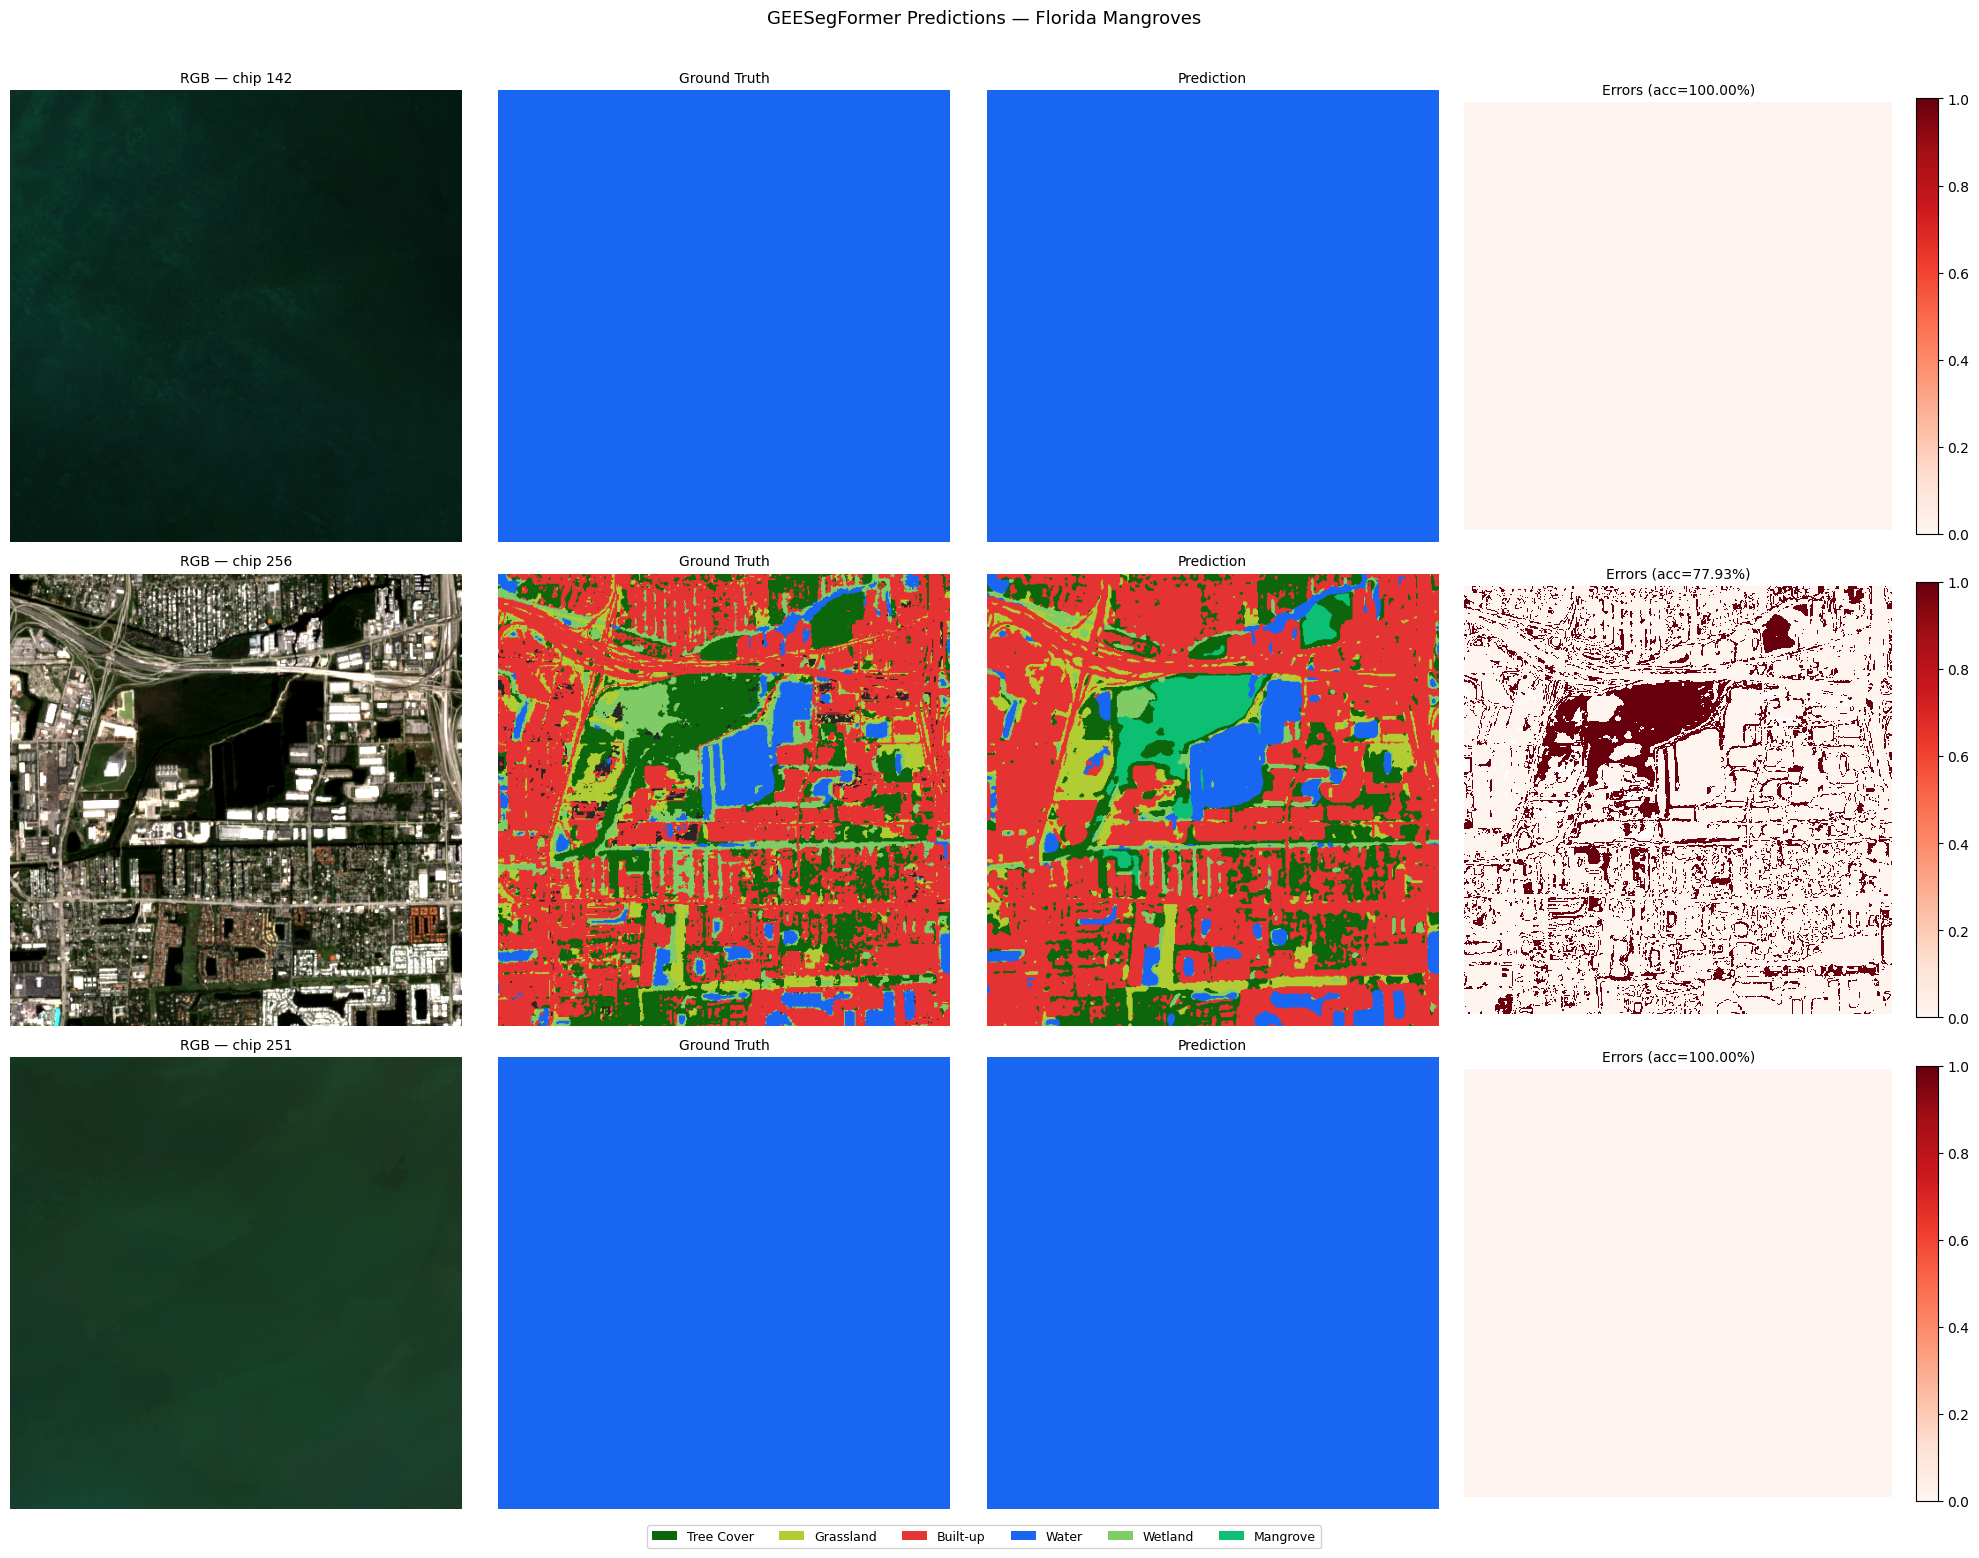

In [17]:
def load_raw_rgb(path, row_off, col_off, patch_size):
    """Load RGB channels directly from GeoTIFF without normalisation."""
    win = rasterio.windows.Window(col_off, row_off, patch_size, patch_size)
    with rasterio.open(path) as src:
        r = src.read(1, window=win).astype(np.float32)  # Red
        g = src.read(2, window=win).astype(np.float32)  # Green
        b = src.read(3, window=win).astype(np.float32)  # Blue
    rgb = np.stack([r, g, b], axis=-1)
    rgb = np.clip(rgb / 3000.0, 0.0, 1.0)   # scale S2 raw → [0,1]
    return rgb


def make_label_rgb(label_2d):
    """Convert class-index map → displayable RGB image."""
    h, w = label_2d.shape
    rgb = np.zeros((h, w, 3), dtype=np.float32)
    for i, color in enumerate(CLASS_COLORS):
        rgb[label_2d == i] = color
    rgb[label_2d == IGNORE_INDEX] = [0.15, 0.15, 0.15]
    return rgb


@torch.no_grad()
def visualize_predictions(model, dataset, n_samples=3, device=DEVICE):
    """Show RGB / ground-truth / prediction / error for random val chips."""
    has_catalog = dataset.catalog is not None
    if not has_catalog:
        print('Warning: catalog.json not found — skipping RGB column.')
        n_cols = 3
    else:
        n_cols = 4

    model.eval().to(device)
    indices = random.sample(range(len(dataset)), min(n_samples, len(dataset)))

    fig, axes = plt.subplots(len(indices), n_cols, figsize=(5 * n_cols, 5 * len(indices)))
    if len(indices) == 1:
        axes = axes[np.newaxis, :]

    for row, idx in enumerate(indices):
        features, label = dataset[idx]

        # Model prediction
        pred_logits = model(features.unsqueeze(0).to(device))
        pred_mask   = torch.argmax(pred_logits.squeeze(0), dim=0).cpu().numpy()
        label_np    = label.numpy()

        # Error map
        valid = label_np != IGNORE_INDEX
        error = np.zeros_like(label_np, dtype=np.float32)
        error[valid]  = (pred_mask[valid] != label_np[valid]).astype(np.float32)
        error[~valid] = np.nan

        col = 0
        if has_catalog:
            path, row_off, col_off = dataset.catalog[idx]
            rgb = load_raw_rgb(path, row_off, col_off, PATCH_SIZE)
            axes[row, col].imshow(rgb)
            axes[row, col].set_title(f'RGB — chip {idx}', fontsize=10)
            axes[row, col].axis('off')
            col += 1

        axes[row, col].imshow(make_label_rgb(label_np))
        axes[row, col].set_title('Ground Truth', fontsize=10)
        axes[row, col].axis('off')
        col += 1

        axes[row, col].imshow(make_label_rgb(pred_mask))
        axes[row, col].set_title('Prediction', fontsize=10)
        axes[row, col].axis('off')
        col += 1

        im = axes[row, col].imshow(error, cmap='Reds', vmin=0, vmax=1, interpolation='none')
        acc = 1.0 - np.nanmean(error)
        axes[row, col].set_title(f'Errors (acc={acc:.2%})', fontsize=10)
        axes[row, col].axis('off')
        plt.colorbar(im, ax=axes[row, col], fraction=0.046)

    # Legend
    patches = [mpatches.Patch(facecolor=CLASS_COLORS[i], label=CLASS_NAMES[i])
               for i in range(NUM_CLASSES)]
    fig.legend(handles=patches, loc='lower center', ncol=NUM_CLASSES,
               fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.02))

    plt.suptitle('GEESegFormer Predictions — Florida Mangroves', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


visualize_predictions(model, val_dataset, n_samples=3)


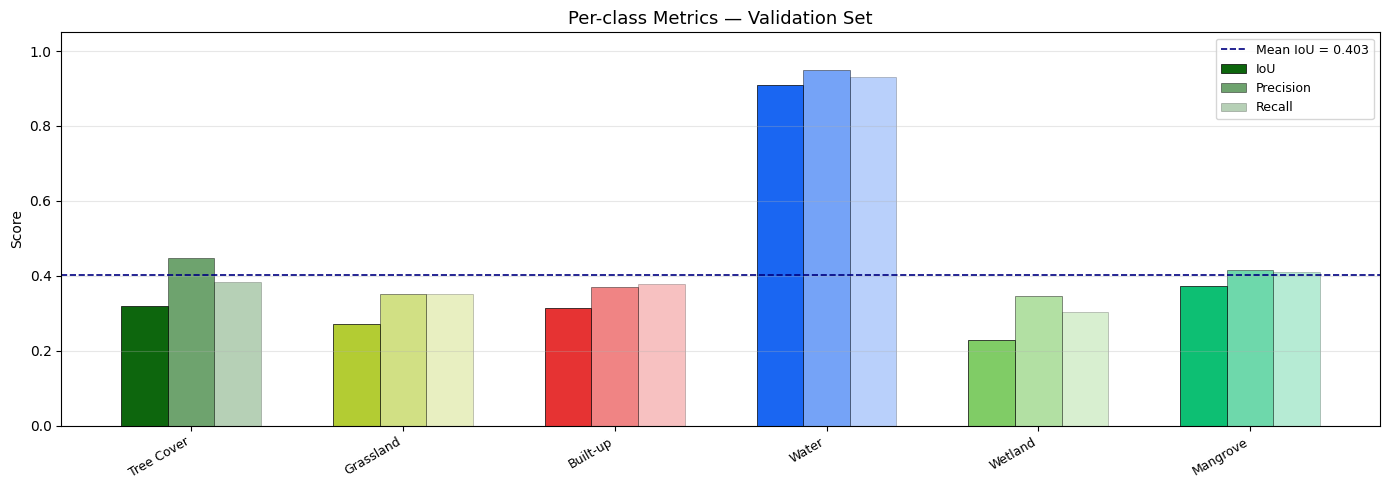

In [18]:
# Per-class IoU bar chart
if 'class_ious' in val_metrics:
    ious = val_metrics['class_ious']
    prec = val_metrics.get('class_precisions', [None]*NUM_CLASSES)
    rec  = val_metrics.get('class_recalls',    [None]*NUM_CLASSES)

    x     = np.arange(NUM_CLASSES)
    width = 0.22

    fig, ax = plt.subplots(figsize=(14, 5))
    colors = [CLASS_COLORS[i] for i in range(NUM_CLASSES)]

    ax.bar(x - width, ious, width, label='IoU',       color=colors, edgecolor='black', linewidth=0.5)
    if prec[0] is not None:
        ax.bar(x,         prec, width, label='Precision', color=colors, edgecolor='black', linewidth=0.5, alpha=0.6)
        ax.bar(x + width, rec,  width, label='Recall',    color=colors, edgecolor='black', linewidth=0.5, alpha=0.3)

    ax.set_xticks(x)
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.set_title('Per-class Metrics — Validation Set', fontsize=13)
    ax.axhline(val_metrics['IoU'], color='navy', linestyle='--', linewidth=1.2,
               label=f'Mean IoU = {val_metrics["IoU"]:.3f}')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

## Summary

| Setting | Value |
|---------|-------|
| Input mode | `INPUT_MODE` |
| Input channels | `IN_CHANNELS` |
| Patch size | 512 × 512 |
| Backbone | SegFormer-B2 (pretrained ADE20K) |
| Loss | JaccardLoss (CE + IoU, α=0.4) |
| Optimizer | AdamW, lr=5e-5, wd=0.01 |
| Scheduler | CosineAnnealing |

### Next Steps
- Try `INPUT_MODE = 'rgbn'` or `'embeddings'` to ablate feature contributions
- Try `SEGFORMER_WEIGHTS = 'nvidia/segformer-b5-finetuned-ade-640-640'` for stronger backbone
- Add overlap-based tiling (stride < patch_size) for denser training chips
- Run on additional regions beyond Florida